<h2>Forecasting Models:</h2>
<h3> MODEL 1: ARIMA</h3>

In [1]:
#load necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [2]:
#loading monthly dataset
monthly_df = pd.read_csv("monthly_dataset.csv")
monthly_df['Date_Posted'] = pd.to_datetime(monthly_df['Date_Posted'])
monthly_df.head()

,Date_Posted,Job_Count
0,2024-06-01,215
1,2024-07-01,202
2,2024-08-01,222
3,2024-09-01,224
4,2024-10-01,239


<h4>Plot ACF:</h4>
<p>The Autocorrelation Function (ACF) helps determine the Moving Average (MA) component (q) by showing how strongly the current month's job count is correlated with previous months.</p>

<Figure size 1000x500 with 0 Axes>

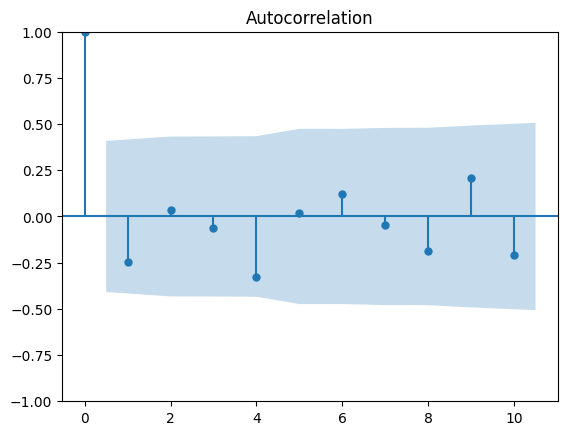

In [3]:
plt.figure(figsize=(10,5))
plot_acf(monthly_df['Job_Count'],lags=10)
plt.show()

<h4>Interpretation:</h4>
<p><b>From ACF plot:</b>

None of the lags (except lag 0) clearly exceed the confidence interval.
The autocorrelations are relatively weak.
There isn't a sharp cutoff that would suggest a strong MA component.

<b>Conclusion:</b>

Start with q = 0 (or at most 1).</p>

<h4>Plot PACF:</h4>
<p>The Partial Autocorrelation Function (PACF) helps determine the Autoregressive (AR) component (p) by measuring the direct relationship between the current month's job count and previous months, after removing the influence of intermediate lags.</p>

<Figure size 1000x500 with 0 Axes>

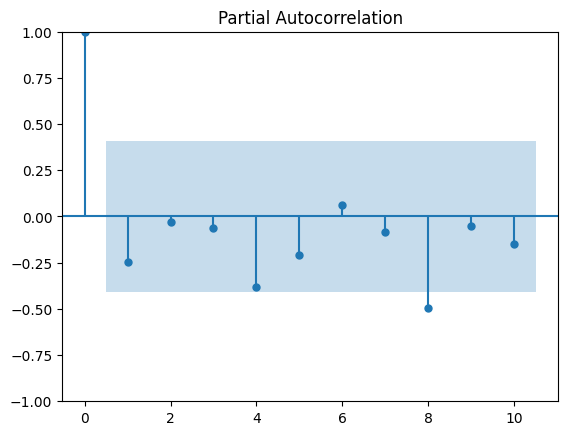

In [4]:
plt.figure(figsize=(10,5))
plot_pacf(monthly_df['Job_Count'],lags=10,method='ywm')
plt.show()

<h4>Interpretation:</h4>
<p><b>From PACF plot:</b>
<ul><li>Most lags lie within the confidence interval.</li>
<li>Lag 8 slightly exceeds the confidence bounds, but with only 24 observations, we generally do not choose such a high order because it increases the risk of overfitting.</li>
<li>There isn't a strong AR cutoff either.</li></ul>

<b>Conclusion:</b>

Start with p = 1.</p>

<h5>Therefore, our first ARIMA model will be: ARIMA(1,0,0)</h5>
where:
<ul>
<li>p = 1 (from PACF)</li>
<li>d = 0 (ADF test confirmed stationarity)</li>
<li>q = 0 (from ACF)</li></ul>
<h5>But rather than relying on a single ACF/PACF interpretation, it's standard practice to compare several candidate ARIMA models and select the best one using the Akaike Information Criterion (AIC).</h5>
Hence, we will fit several candidate models and Then compare their AIC values and select the best-performing model before evaluating it on the test set. 
<li>ARIMA(1,0,0)</li>
<li>ARIMA(0,0,1)</li>
<li>ARIMA(1,0,1)</li>
<li>ARIMA(2,0,0)</li>
<li>ARIMA(2,0,1)</li>

In [5]:
#To find the best ARIMA model
from statsmodels.tsa.arima.model import ARIMA
orders = [
    (1,0,0),
    (0,0,1),
    (1,0,1),
    (2,0,0),
    (2,0,1)
]
results = []
for order in orders:
    model = ARIMA(monthly_df['Job_Count'], order=order)
    fitted = model.fit()
    results.append({
        "Order": order,
        "AIC": fitted.aic,
        "BIC": fitted.bic
    })
comparison = pd.DataFrame(results)
comparison.sort_values("AIC")

C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


,Order,AIC,BIC
2,"(1, 0, 1)",185.974902,190.516879
1,"(0, 0, 1)",187.854270,191.260752
4,"(2, 0, 1)",187.957316,193.634787
0,"(1, 0, 0)",187.984899,191.391382
3,"(2, 0, 0)",189.960971,194.502947


<h3>Interpretation:</h3>
<p>Multiple ARIMA models were evaluated using the Akaike Information Criterion (AIC). Among the candidate models, ARIMA(1,0,1) achieved the lowest AIC value (185.97), indicating the best balance between model fit and complexity. Therefore, ARIMA(1,0,1) was selected as the final forecasting model.</p>

In [6]:
#Train-Test_split
# Train-test split (80-20)
train_size = int(len(monthly_df) * 0.8)
train = monthly_df['Job_Count'][:train_size]
test = monthly_df['Job_Count'][train_size:]
print("Training observations:", len(train))
print("Testing observations:", len(test))

Training observations: 18
Testing observations: 5


In [7]:
from statsmodels.tsa.arima.model import ARIMA

# Train ARIMA(1,0,1)
model = ARIMA(train, order=(1,0,1))

model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:              Job_Count   No. Observations:                   18
Model:                 ARIMA(1, 0, 1)   Log Likelihood                 -70.476
Date:                Thu, 09 Jul 2026   AIC                            148.953
Time:                        18:45:58   BIC                            152.514
Sample:                             0   HQIC                           149.444
                                 - 18                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const        218.2440      1.215    179.646      0.000     215.863     220.625
ar.L1          0.4308      0.623      0.691      0.489      -0.791       1.652
ma.L1         -0.9997    178.052     -0.006      0.9

In [8]:
#Forecast test period
# Forecast
forecast = model_fit.forecast(steps=len(test))
forecast

18    217.433729
19    217.894958
20    218.093637
21    218.179220
22    218.216085
Name: predicted_mean, dtype: float64

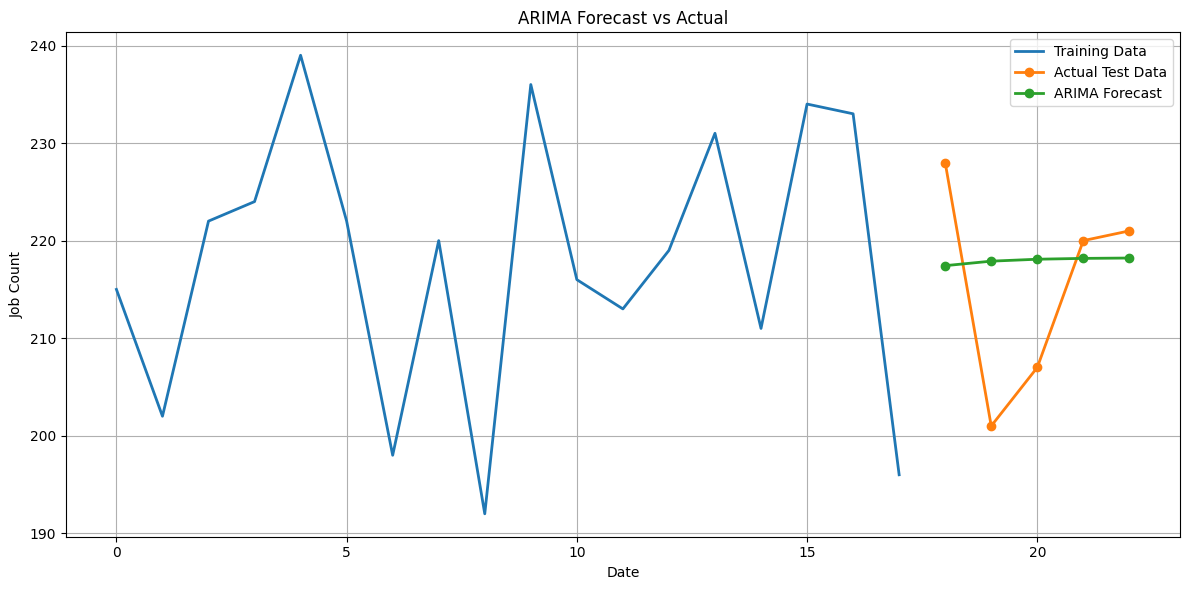

In [9]:
#visualize actual vs forcast
plt.figure(figsize=(12,6))
plt.plot(train.index, train.values,
         label='Training Data',
         linewidth=2)
plt.plot(test.index, test.values,
         label='Actual Test Data',
         marker='o',
         linewidth=2)
plt.plot(test.index, forecast.values,
         label='ARIMA Forecast',
         marker='o',
         linewidth=2)
plt.title("ARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Job Count")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [10]:
#Evaluate model
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = mean_absolute_percentage_error(test, forecast)
print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 8.631912121201395
RMSE: 10.30747183053612
MAPE: 0.040972686324926455


<h3> ARIMA FORECASTING INTERPRETATION:</h3>
<p>The ARIMA(1,0,1) model was selected based on the lowest Akaike Information Criterion (AIC) among several candidate models. Model evaluation on the test dataset resulted in an MAE of 8.63, RMSE of 10.31, and MAPE of 4.10%. These results indicate excellent forecasting performance, with prediction errors remaining below 5% on average. The forecast closely follows the overall hiring trend, although minor month-to-month fluctuations are smoothed.</p>

<h3> MODEL 2: PROPHET</h3>

In [11]:
from prophet import Prophet
prophet_df = monthly_df[['Date_Posted', 'Job_Count']].copy()
prophet_df.columns = ['ds', 'y']
prophet_df.head()

,ds,y
0,2024-06-01,215
1,2024-07-01,202
2,2024-08-01,222
3,2024-09-01,224
4,2024-10-01,239


In [12]:
#Train-test-split same as arima
train_size = int(len(prophet_df) * 0.8)
train = prophet_df.iloc[:train_size]
test = prophet_df.iloc[train_size:]

In [13]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)
model.fit(train)

18:46:02 - cmdstanpy - INFO - Chain [1] start processing
18:46:06 - cmdstanpy - INFO - Chain [1] done processing


In [14]:
#Forecast test period
future = model.make_future_dataframe(
    periods=len(test),
    freq='MS')
forecast = model.predict(future)

In [15]:
#Extract predictions
forecast_test = forecast.tail(len(test))
forecast_test[['ds', 'yhat']]

,ds,yhat
18,2025-12-01,218.079877
19,2026-01-01,239.325461
20,2026-02-01,179.095290
21,2026-03-01,228.567644
22,2026-04-01,250.038947


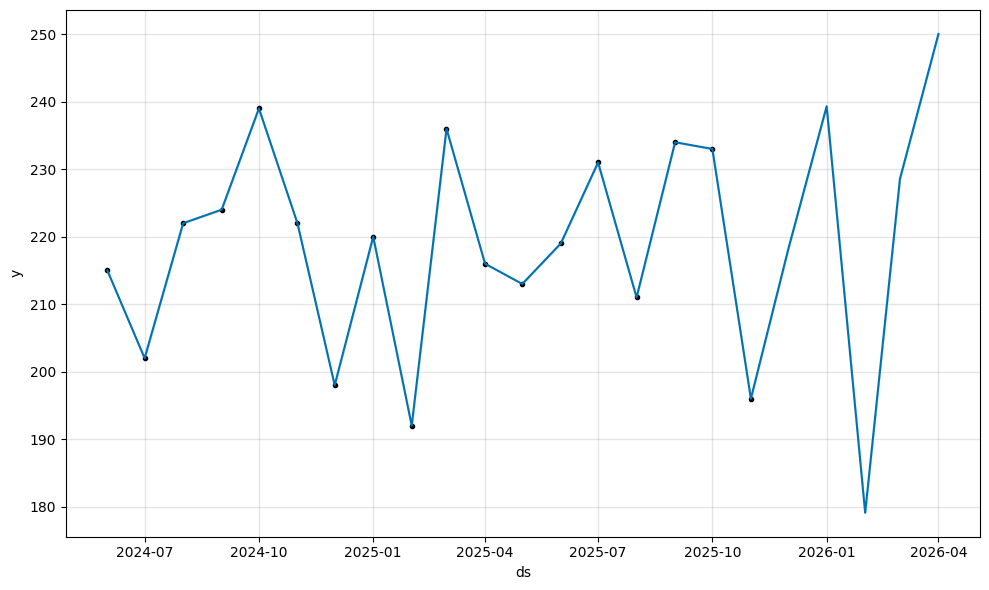

In [16]:
#plot forecast
fig = model.plot(forecast)

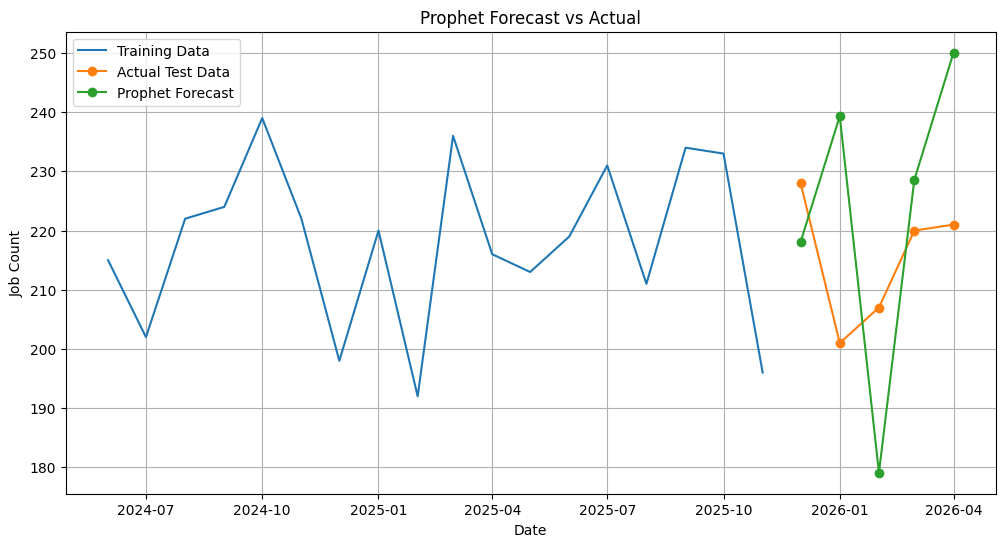

In [17]:
#Compare actual vs forecast
plt.figure(figsize=(12,6))
plt.plot(
    train['ds'],
    train['y'],
    label='Training Data')
plt.plot(
    test['ds'],
    test['y'],
    label='Actual Test Data',
    marker='o')
plt.plot(
    forecast_test['ds'],
    forecast_test['yhat'],
    label='Prophet Forecast',
    marker='o')
plt.title("Prophet Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Job Count")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
#evaluate
mae = mean_absolute_error(
    test['y'],
    forecast_test['yhat'])
rmse = np.sqrt(
    mean_squared_error(
        test['y'],
        forecast_test['yhat']))
mape = mean_absolute_percentage_error(
    test['y'],
    forecast_test['yhat'])
print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 22.751376856146152
RMSE: 25.544422330768402
MAPE: 0.10786607841904398


<h3>Observation of two models:</h3>
<p>The Prophet model was trained using the monthly AI job postings dataset and evaluated on the test data. The model achieved an MAE of 22.75, RMSE of 25.54, and MAPE of 10.79%. Compared with ARIMA, Prophet produced larger forecasting errors and overestimated the variability in job postings. This suggests that Prophet was less suitable for this relatively short and stable time series.</p>
<p>Therefore ARIMA is better than prophet for this dataset.</p>

<h3>MODEL 3: XGBoost</h3>

In [19]:
#using forcasting_dataset for XGBoost
forecast_df = pd.read_csv("forecasting_dataset.csv")
forecast_df.head()

,Date_Posted,Job_Count,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Rolling_Mean_6,Rolling_STD_3,MoM_Growth,Trend,Year,Month,Quarter
0,2024-11-01,222,239.0,224.0,222.0,228.333333,220.666667,9.291573,-0.071130,6,2024,11,4
1,2024-12-01,198,222.0,239.0,224.0,219.666667,217.833333,20.599353,-0.108108,7,2024,12,4
2,2025-01-01,220,198.0,222.0,239.0,213.333333,220.833333,13.316656,0.111111,8,2025,1,1
3,2025-02-01,192,220.0,198.0,222.0,203.333333,215.833333,14.742230,-0.127273,9,2025,2,1
4,2025-03-01,236,192.0,220.0,198.0,216.000000,217.833333,22.271057,0.229167,10,2025,3,1


In [20]:
#seperate features and target
forecast_df['Date_Posted'] = pd.to_datetime(forecast_df['Date_Posted'])
X = forecast_df.drop(columns=['Date_Posted','Job_Count'])
y = forecast_df['Job_Count']

In [21]:
#Time based train-test split
split = int(len(forecast_df) * 0.8)
X_train = X[:split]
X_test = X[split:]
y_train = y[:split]
y_test = y[split:]

In [22]:
from xgboost import XGBRegressor
model = XGBRegressor(
    n_estimators=50,
    max_depth=2,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train, y_train)

C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:297: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(dtype):
C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:299: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  elif is_categorical_dtype(dtype) and enable_categorical:
C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:364: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(data):


XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=1, colsample_bynode=1, colsample_bytree=0.8,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, gamma=0, gpu_id=-1, grow_policy='depthwise',
             importance_type=None, interaction_constraints='',
             learning_rate=0.1, max_bin=256, max_cat_to_onehot=4,
             max_delta_step=0, max_depth=2, max_leaves=0, min_child_weight=1,
             missing=nan, monotone_constraints='()', n_estimators=50, n_jobs=0,
             num_parallel_tree=1, predictor='auto', random_state=42,
             reg_alpha=0, reg_lambda=1, ...)

In [23]:
predictions = model.predict(X_test)

C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:297: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(dtype):
C:\Users\zamiy\AppData\Roaming\Python\Python311\site-packages\xgboost\data.py:299: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  elif is_categorical_dtype(dtype) and enable_categorical:


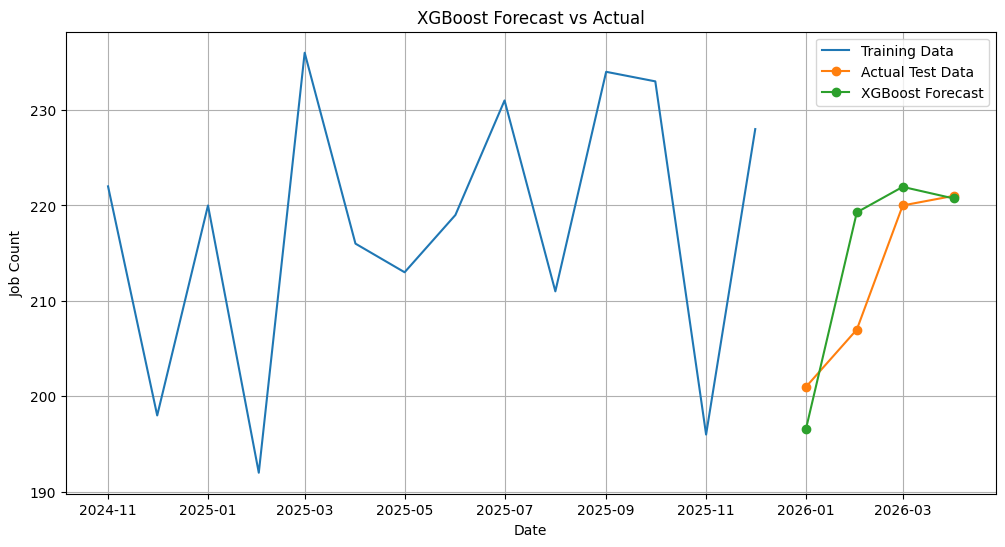

In [24]:
plt.figure(figsize=(12,6))
plt.plot(
    forecast_df['Date_Posted'][:split],
    y_train,
    label='Training Data')
plt.plot(
    forecast_df['Date_Posted'][split:],
    y_test,
    label='Actual Test Data',
    marker='o')
plt.plot(
    forecast_df['Date_Posted'][split:],
    predictions,
    label='XGBoost Forecast',
    marker='o')
plt.title("XGBoost Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Job Count")
plt.legend()
plt.grid(True)
plt.show()

In [25]:
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
mape = mean_absolute_percentage_error(y_test, predictions)

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 4.717399597167969
RMSE: 6.591842371863075
MAPE: 0.022788266681417323


<h3>Observation for all three Models:</h3>
<p>Three forecasting models—ARIMA, Prophet, and XGBoost—were evaluated using MAE, RMSE, and MAPE. </p>
    <p>XGBoost achieved the best overall performance with an MAE of 4.72, RMSE of 6.59, and MAPE of 2.28%, outperforming both ARIMA and Prophet. </p>
        <p>This indicates that the machine learning model, supported by engineered lag and rolling statistical features, was better able to capture the short-term dynamics of the AI job market in the available dataset.</p>